# Tech Challenge - Fase 3
# Análise Exploratória de Dados (EDA): Atrasos de Voos nos EUA

**Objetivo:** Investigar dados de voos nos EUA para entender padrões de atrasos utilizando estatísticas descritivas e visualizações com insights.

**Base de Dados:**
- airlines.csv: Informações sobre companhias aéreas
- airports.csv: Informações sobre aeroportos
- flights.csv: Dados detalhados de voos (2015)


## 1. Importação de Bibliotecas

Importando as bibliotecas necessárias para análise de dados e visualização.


In [24]:
# Importar bibliotecas necessárias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# Configurações
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# Configurar tamanho padrão dos gráficos
plt.rcParams['figure.figsize'] = (12, 6)

print("✓ Bibliotecas importadas com sucesso!")


✓ Bibliotecas importadas com sucesso!


## 2. Carregamento e Exploração Inicial dos Dados

Carregando os três arquivos CSV e realizando uma primeira exploração dos dados.


In [25]:
# Carregar os dados
print("Carregando dados...")
airlines = pd.read_csv('airlines.csv')
airports = pd.read_csv('airports.csv')
flights = pd.read_csv('flights.csv')

print(f"\n✓ Dados carregados com sucesso!")
print(f"\nTamanho dos datasets:")
print(f"  - Airlines: {airlines.shape[0]} linhas x {airlines.shape[1]} colunas")
print(f"  - Airports: {airports.shape[0]} linhas x {airports.shape[1]} colunas")
print(f"  - Flights: {flights.shape[0]} linhas x {flights.shape[1]} colunas")


Carregando dados...

✓ Dados carregados com sucesso!

Tamanho dos datasets:
  - Airlines: 14 linhas x 2 colunas
  - Airports: 322 linhas x 7 colunas
  - Flights: 5819079 linhas x 31 colunas


In [26]:
# Visualizar primeiras linhas de cada dataset
print("=" * 80)
print("AIRLINES - Primeiras 5 linhas:")
print("=" * 80)
display(airlines.head())

print("\n" + "=" * 80)
print("AIRPORTS - Primeiras 5 linhas:")
print("=" * 80)
display(airports.head())

print("\n" + "=" * 80)
print("FLIGHTS - Primeiras 5 linhas:")
print("=" * 80)
display(flights.head())


AIRLINES - Primeiras 5 linhas:


,IATA_CODE,AIRLINE
0,UA,United Air Lines Inc.
1,AA,American Airlines Inc.
2,US,US Airways Inc.
3,F9,Frontier Airlines Inc.
4,B6,JetBlue Airways



AIRPORTS - Primeiras 5 linhas:


,IATA_CODE,AIRPORT,CITY,STATE,COUNTRY,LATITUDE,LONGITUDE
0,ABE,Lehigh Valley International Airport,Allentown,PA,USA,40.65236,-75.44040
1,ABI,Abilene Regional Airport,Abilene,TX,USA,32.41132,-99.68190
2,ABQ,Albuquerque International Sunport,Albuquerque,NM,USA,35.04022,-106.60919
3,ABR,Aberdeen Regional Airport,Aberdeen,SD,USA,45.44906,-98.42183
4,ABY,Southwest Georgia Regional Airport,Albany,GA,USA,31.53552,-84.19447



FLIGHTS - Primeiras 5 linhas:


,YEAR,MONTH,DAY,DAY_OF_WEEK,AIRLINE,FLIGHT_NUMBER,TAIL_NUMBER,ORIGIN_AIRPORT,DESTINATION_AIRPORT,SCHEDULED_DEPARTURE,DEPARTURE_TIME,DEPARTURE_DELAY,TAXI_OUT,WHEELS_OFF,SCHEDULED_TIME,ELAPSED_TIME,AIR_TIME,DISTANCE,WHEELS_ON,TAXI_IN,SCHEDULED_ARRIVAL,ARRIVAL_TIME,ARRIVAL_DELAY,DIVERTED,CANCELLED,CANCELLATION_REASON,AIR_SYSTEM_DELAY,SECURITY_DELAY,AIRLINE_DELAY,LATE_AIRCRAFT_DELAY,WEATHER_DELAY
0,2015,1,1,4,AS,98,N407AS,ANC,SEA,5,2354.0,-11.0,21.0,15.0,205.0,194.0,169.0,1448,404.0,4.0,430,408.0,-22.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
1,2015,1,1,4,AA,2336,N3KUAA,LAX,PBI,10,2.0,-8.0,12.0,14.0,280.0,279.0,263.0,2330,737.0,4.0,750,741.0,-9.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
2,2015,1,1,4,US,840,N171US,SFO,CLT,20,18.0,-2.0,16.0,34.0,286.0,293.0,266.0,2296,800.0,11.0,806,811.0,5.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
3,2015,1,1,4,AA,258,N3HYAA,LAX,MIA,20,15.0,-5.0,15.0,30.0,285.0,281.0,258.0,2342,748.0,8.0,805,756.0,-9.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,2015,1,1,4,AS,135,N527AS,SEA,ANC,25,24.0,-1.0,11.0,35.0,235.0,215.0,199.0,1448,254.0,5.0,320,259.0,-21.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN


In [27]:
# Informações sobre os tipos de dados e valores faltantes
print("=" * 80)
print("INFORMAÇÕES SOBRE OS DADOS - FLIGHTS")
print("=" * 80)
flights.info()

print("\n" + "=" * 80)
print("VALORES FALTANTES - FLIGHTS")
print("=" * 80)
missing_data = pd.DataFrame({
    'Coluna': flights.columns,
    'Valores Faltantes': flights.isnull().sum(),
    'Percentual (%)': (flights.isnull().sum() / len(flights) * 100).round(2)
})
missing_data = missing_data[missing_data['Valores Faltantes'] > 0].sort_values('Valores Faltantes', ascending=False)
display(missing_data)


INFORMAÇÕES SOBRE OS DADOS - FLIGHTS
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5819079 entries, 0 to 5819078
Data columns (total 31 columns):
 #   Column               Dtype  
---  ------               -----  
 0   YEAR                 int64  
 1   MONTH                int64  
 2   DAY                  int64  
 3   DAY_OF_WEEK          int64  
 4   AIRLINE              object 
 5   FLIGHT_NUMBER        int64  
 6   TAIL_NUMBER          object 
 7   ORIGIN_AIRPORT       object 
 8   DESTINATION_AIRPORT  object 
 9   SCHEDULED_DEPARTURE  int64  
 10  DEPARTURE_TIME       float64
 11  DEPARTURE_DELAY      float64
 12  TAXI_OUT             float64
 13  WHEELS_OFF           float64
 14  SCHEDULED_TIME       float64
 15  ELAPSED_TIME         float64
 16  AIR_TIME             float64
 17  DISTANCE             int64  
 18  WHEELS_ON            float64
 19  TAXI_IN              float64
 20  SCHEDULED_ARRIVAL    int64  
 21  ARRIVAL_TIME         float64
 22  ARRIVAL_DELAY        float64


,Coluna,Valores Faltantes,Percentual (%)
CANCELLATION_REASON,CANCELLATION_REASON,5729195,98.46
SECURITY_DELAY,SECURITY_DELAY,4755640,81.72
AIR_SYSTEM_DELAY,AIR_SYSTEM_DELAY,4755640,81.72
LATE_AIRCRAFT_DELAY,LATE_AIRCRAFT_DELAY,4755640,81.72
WEATHER_DELAY,WEATHER_DELAY,4755640,81.72
AIRLINE_DELAY,AIRLINE_DELAY,4755640,81.72
ARRIVAL_DELAY,ARRIVAL_DELAY,105071,1.81
ELAPSED_TIME,ELAPSED_TIME,105071,1.81
AIR_TIME,AIR_TIME,105071,1.81
TAXI_IN,TAXI_IN,92513,1.59


## 3. Estatísticas Descritivas

Calculando estatísticas descritivas para compreender a distribuição dos dados numéricos.


In [28]:
# Estatísticas descritivas gerais
print("=" * 80)
print("ESTATÍSTICAS DESCRITIVAS - DATASET FLIGHTS")
print("=" * 80)
display(flights.describe())

# Estatísticas adicionais sobre atrasos
print("\n" + "=" * 80)
print("ESTATÍSTICAS ESPECÍFICAS - ATRASOS")
print("=" * 80)

delay_stats = pd.DataFrame({
    'Métrica': ['Média', 'Mediana', 'Desvio Padrão', 'Mínimo', 'Máximo', 'Q1 (25%)', 'Q3 (75%)'],
    'Atraso Partida': [
        flights['DEPARTURE_DELAY'].mean(),
        flights['DEPARTURE_DELAY'].median(),
        flights['DEPARTURE_DELAY'].std(),
        flights['DEPARTURE_DELAY'].min(),
        flights['DEPARTURE_DELAY'].max(),
        flights['DEPARTURE_DELAY'].quantile(0.25),
        flights['DEPARTURE_DELAY'].quantile(0.75)
    ],
    'Atraso Chegada': [
        flights['ARRIVAL_DELAY'].mean(),
        flights['ARRIVAL_DELAY'].median(),
        flights['ARRIVAL_DELAY'].std(),
        flights['ARRIVAL_DELAY'].min(),
        flights['ARRIVAL_DELAY'].max(),
        flights['ARRIVAL_DELAY'].quantile(0.25),
        flights['ARRIVAL_DELAY'].quantile(0.75)
    ]
})

display(delay_stats.round(2))


ESTATÍSTICAS DESCRITIVAS - DATASET FLIGHTS


,YEAR,MONTH,DAY,DAY_OF_WEEK,FLIGHT_NUMBER,SCHEDULED_DEPARTURE,DEPARTURE_TIME,DEPARTURE_DELAY,TAXI_OUT,WHEELS_OFF,SCHEDULED_TIME,ELAPSED_TIME,AIR_TIME,DISTANCE,WHEELS_ON,TAXI_IN,SCHEDULED_ARRIVAL,ARRIVAL_TIME,ARRIVAL_DELAY,DIVERTED,CANCELLED,AIR_SYSTEM_DELAY,SECURITY_DELAY,AIRLINE_DELAY,LATE_AIRCRAFT_DELAY,WEATHER_DELAY
count,5819079.0,5.819079e+06,5.819079e+06,5.819079e+06,5.819079e+06,5.819079e+06,5.732926e+06,5.732926e+06,5.730032e+06,5.730032e+06,5.819073e+06,5.714008e+06,5.714008e+06,5.819079e+06,5.726566e+06,5.726566e+06,5.819079e+06,5.726566e+06,5.714008e+06,5.819079e+06,5.819079e+06,1.063439e+06,1.063439e+06,1.063439e+06,1.063439e+06,1.063439e+06
mean,2015.0,6.524085e+00,1.570459e+01,3.926941e+00,2.173093e+03,1.329602e+03,1.335204e+03,9.370158e+00,1.607166e+01,1.357171e+03,1.416859e+02,1.370062e+02,1.135116e+02,8.223565e+02,1.471469e+03,7.434971e+00,1.493808e+03,1.476491e+03,4.407057e+00,2.609863e-03,1.544643e-02,1.348057e+01,7.615387e-02,1.896955e+01,2.347284e+01,2.915290e+00
std,0.0,3.405137e+00,8.783425e+00,1.988845e+00,1.757064e+03,4.837518e+02,4.964233e+02,3.708094e+01,8.895574e+00,4.980094e+02,7.521058e+01,7.421107e+01,7.223082e+01,6.077843e+02,5.221879e+02,5.638548e+00,5.071647e+02,5.263197e+02,3.927130e+01,5.102012e-02,1.233201e-01,2.800368e+01,2.143460e+00,4.816164e+01,4.319702e+01,2.043334e+01
min,2015.0,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,-8.200000e+01,1.000000e+00,1.000000e+00,1.800000e+01,1.400000e+01,7.000000e+00,2.100000e+01,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,-8.700000e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,2015.0,4.000000e+00,8.000000e+00,2.000000e+00,7.300000e+02,9.170000e+02,9.210000e+02,-5.000000e+00,1.100000e+01,9.350000e+02,8.500000e+01,8.200000e+01,6.000000e+01,3.730000e+02,1.054000e+03,4.000000e+00,1.110000e+03,1.059000e+03,-1.300000e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,2015.0,7.000000e+00,1.600000e+01,4.000000e+00,1.690000e+03,1.325000e+03,1.330000e+03,-2.000000e+00,1.400000e+01,1.343000e+03,1.230000e+02,1.180000e+02,9.400000e+01,6.470000e+02,1.509000e+03,6.000000e+00,1.520000e+03,1.512000e+03,-5.000000e+00,0.000000e+00,0.000000e+00,2.000000e+00,0.000000e+00,2.000000e+00,3.000000e+00,0.000000e+00
75%,2015.0,9.000000e+00,2.300000e+01,6.000000e+00,3.230000e+03,1.730000e+03,1.740000e+03,7.000000e+00,1.900000e+01,1.754000e+03,1.730000e+02,1.680000e+02,1.440000e+02,1.062000e+03,1.911000e+03,9.000000e+00,1.918000e+03,1.917000e+03,8.000000e+00,0.000000e+00,0.000000e+00,1.800000e+01,0.000000e+00,1.900000e+01,2.900000e+01,0.000000e+00
max,2015.0,1.200000e+01,3.100000e+01,7.000000e+00,9.855000e+03,2.359000e+03,2.400000e+03,1.988000e+03,2.250000e+02,2.400000e+03,7.180000e+02,7.660000e+02,6.900000e+02,4.983000e+03,2.400000e+03,2.480000e+02,2.400000e+03,2.400000e+03,1.971000e+03,1.000000e+00,1.000000e+00,1.134000e+03,5.730000e+02,1.971000e+03,1.331000e+03,1.211000e+03



ESTATÍSTICAS ESPECÍFICAS - ATRASOS


,Métrica,Atraso Partida,Atraso Chegada
0,Média,9.37,4.41
1,Mediana,-2.00,-5.00
2,Desvio Padrão,37.08,39.27
3,Mínimo,-82.00,-87.00
4,Máximo,1988.00,1971.00
5,Q1 (25%),-5.00,-13.00
6,Q3 (75%),7.00,8.00


In [29]:
# Estatísticas sobre cancelamentos e desvios
print("=" * 80)
print("ESTATÍSTICAS - CANCELAMENTOS E DESVIOS")
print("=" * 80)

total_flights = len(flights)
cancelled_flights = flights['CANCELLED'].sum()
diverted_flights = flights['DIVERTED'].sum()

print(f"Total de voos: {total_flights:,}")
print(f"Voos cancelados: {cancelled_flights:,} ({cancelled_flights/total_flights*100:.2f}%)")
print(f"Voos desviados: {diverted_flights:,} ({diverted_flights/total_flights*100:.2f}%)")

print("\n" + "=" * 80)
print("MOTIVOS DE CANCELAMENTO")
print("=" * 80)
if 'CANCELLATION_REASON' in flights.columns:
    cancellation_reasons = flights[flights['CANCELLED'] == 1]['CANCELLATION_REASON'].value_counts()
    for reason, count in cancellation_reasons.items():
        print(f"{reason}: {count:,} ({count/cancelled_flights*100:.2f}%)")


ESTATÍSTICAS - CANCELAMENTOS E DESVIOS
Total de voos: 5,819,079
Voos cancelados: 89,884 (1.54%)
Voos desviados: 15,187 (0.26%)

MOTIVOS DE CANCELAMENTO
B: 48,851 (54.35%)
A: 25,262 (28.11%)
C: 15,749 (17.52%)
D: 22 (0.02%)


In [30]:
# Estatísticas por companhia aérea
print("=" * 80)
print("TOP 10 COMPANHIAS AÉREAS - NÚMERO DE VOOS")
print("=" * 80)

airline_counts = flights['AIRLINE'].value_counts().head(10)
airline_stats = pd.DataFrame({
    'Código': airline_counts.index,
    'Número de Voos': airline_counts.values,
    'Percentual (%)': (airline_counts.values / total_flights * 100).round(2)
})

# Juntar com nomes das companhias
airline_stats = airline_stats.merge(airlines, left_on='Código', right_on='IATA_CODE', how='left')
airline_stats = airline_stats[['Código', 'AIRLINE', 'Número de Voos', 'Percentual (%)']]
display(airline_stats)


TOP 10 COMPANHIAS AÉREAS - NÚMERO DE VOOS


,Código,AIRLINE,Número de Voos,Percentual (%)
0,WN,Southwest Airlines Co.,1261855,21.68
1,DL,Delta Air Lines Inc.,875881,15.05
2,AA,American Airlines Inc.,725984,12.48
3,OO,Skywest Airlines Inc.,588353,10.11
4,EV,Atlantic Southeast Airlines,571977,9.83
5,UA,United Air Lines Inc.,515723,8.86
6,MQ,American Eagle Airlines Inc.,294632,5.06
7,B6,JetBlue Airways,267048,4.59
8,US,US Airways Inc.,198715,3.41
9,AS,Alaska Airlines Inc.,172521,2.96


## 4. Análise de Distribuição dos Dados

Examinando a distribuição das variáveis-chave relacionadas a atrasos.


In [31]:
# Distribuição temporal - voos por mês
print("=" * 80)
print("DISTRIBUIÇÃO DE VOOS POR MÊS")
print("=" * 80)

monthly_flights = flights.groupby('MONTH').size()
month_names = ['Jan', 'Fev', 'Mar', 'Abr', 'Mai', 'Jun', 'Jul', 'Ago', 'Set', 'Out', 'Nov', 'Dez']

monthly_df = pd.DataFrame({
    'Mês': [month_names[i-1] for i in monthly_flights.index],
    'Número de Voos': monthly_flights.values,
    'Percentual (%)': (monthly_flights.values / total_flights * 100).round(2)
})

display(monthly_df)


DISTRIBUIÇÃO DE VOOS POR MÊS


,Mês,Número de Voos,Percentual (%)
0,Jan,469968,8.08
1,Fev,429191,7.38
2,Mar,504312,8.67
3,Abr,485151,8.34
4,Mai,496993,8.54
5,Jun,503897,8.66
6,Jul,520718,8.95
7,Ago,510536,8.77
8,Set,464946,7.99
9,Out,486165,8.35


In [32]:
# Distribuição por dia da semana
print("=" * 80)
print("DISTRIBUIÇÃO DE VOOS POR DIA DA SEMANA")
print("=" * 80)

day_of_week_flights = flights.groupby('DAY_OF_WEEK').size()
day_names = ['Segunda', 'Terça', 'Quarta', 'Quinta', 'Sexta', 'Sábado', 'Domingo']

day_df = pd.DataFrame({
    'Dia da Semana': [day_names[i-1] for i in day_of_week_flights.index],
    'Número de Voos': day_of_week_flights.values,
    'Percentual (%)': (day_of_week_flights.values / total_flights * 100).round(2)
})

display(day_df)


DISTRIBUIÇÃO DE VOOS POR DIA DA SEMANA


,Dia da Semana,Número de Voos,Percentual (%)
0,Segunda,865543,14.87
1,Terça,844600,14.51
2,Quarta,855897,14.71
3,Quinta,872521,14.99
4,Sexta,862209,14.82
5,Sábado,700545,12.04
6,Domingo,817764,14.05


## 5. Visualizações Básicas

Criando histogramas, gráficos de barras e boxplots para visualizar distribuições.


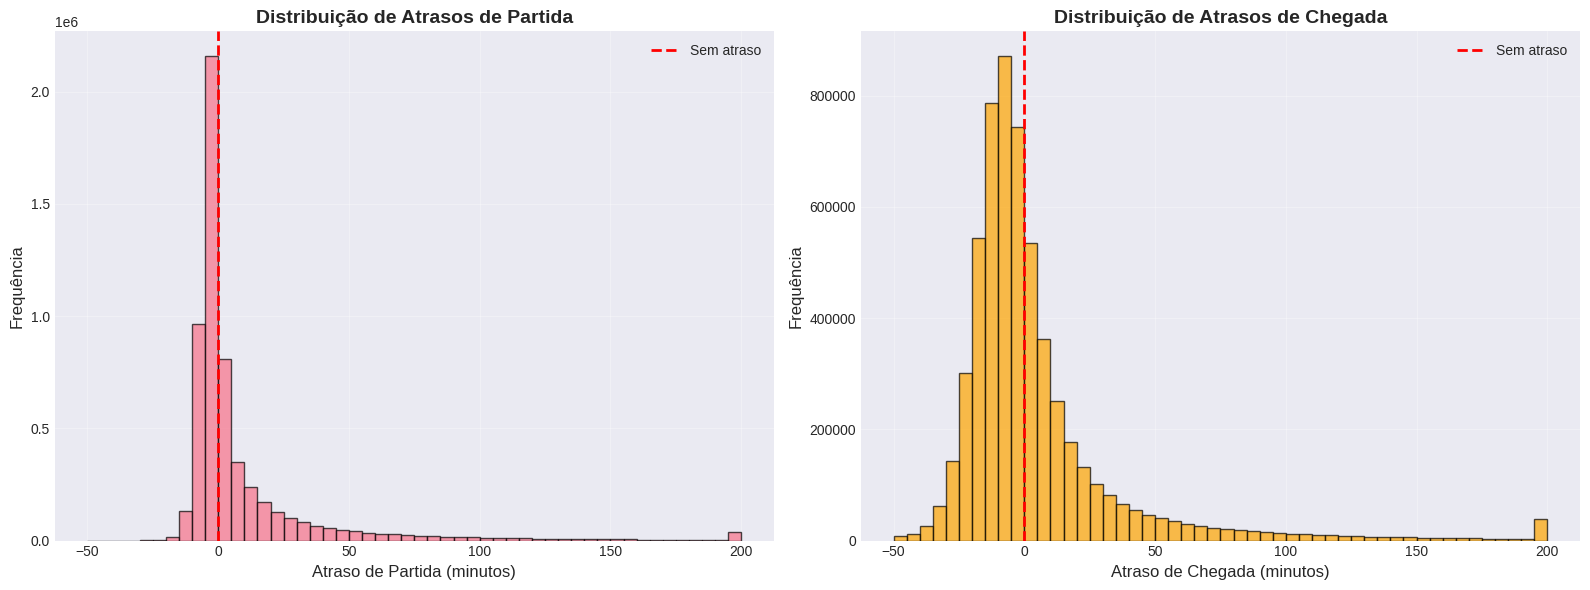

📊 Insight: A maioria dos voos tem atrasos próximos de zero, com uma distribuição assimétrica positiva.


In [33]:
# Histograma - Distribuição de atrasos de partida
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Atraso de partida (limitado para melhor visualização)
axes[0].hist(flights['DEPARTURE_DELAY'].dropna().clip(-50, 200), bins=50, edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Atraso de Partida (minutos)', fontsize=12)
axes[0].set_ylabel('Frequência', fontsize=12)
axes[0].set_title('Distribuição de Atrasos de Partida', fontsize=14, fontweight='bold')
axes[0].axvline(x=0, color='red', linestyle='--', linewidth=2, label='Sem atraso')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Atraso de chegada (limitado para melhor visualização)
axes[1].hist(flights['ARRIVAL_DELAY'].dropna().clip(-50, 200), bins=50, edgecolor='black', alpha=0.7, color='orange')
axes[1].set_xlabel('Atraso de Chegada (minutos)', fontsize=12)
axes[1].set_ylabel('Frequência', fontsize=12)
axes[1].set_title('Distribuição de Atrasos de Chegada', fontsize=14, fontweight='bold')
axes[1].axvline(x=0, color='red', linestyle='--', linewidth=2, label='Sem atraso')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("📊 Insight: A maioria dos voos tem atrasos próximos de zero, com uma distribuição assimétrica positiva.")


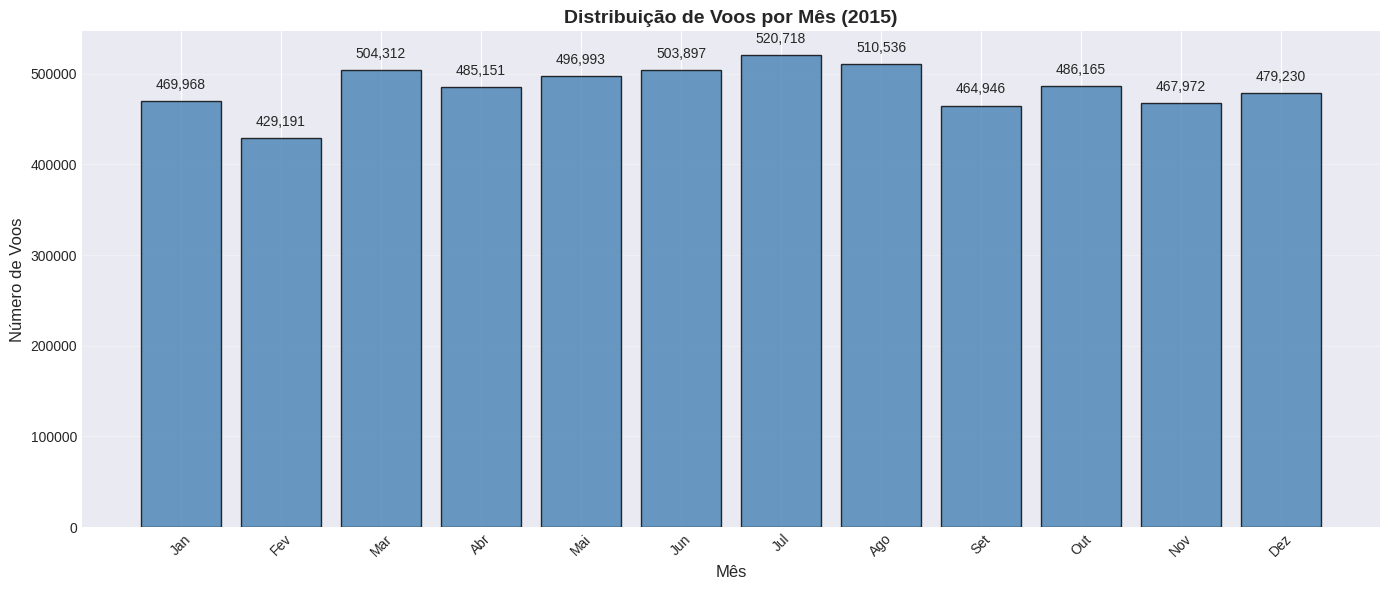

📊 Insight: Analise se há sazonalidade nos voos ao longo do ano.


In [34]:
# Gráfico de barras - Voos por mês
plt.figure(figsize=(14, 6))
plt.bar(month_names, monthly_flights.values, color='steelblue', edgecolor='black', alpha=0.8)
plt.xlabel('Mês', fontsize=12)
plt.ylabel('Número de Voos', fontsize=12)
plt.title('Distribuição de Voos por Mês (2015)', fontsize=14, fontweight='bold')
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)

# Adicionar valores no topo das barras
for i, v in enumerate(monthly_flights.values):
    plt.text(i, v + 10000, f'{v:,}', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

print("📊 Insight: Analise se há sazonalidade nos voos ao longo do ano.")


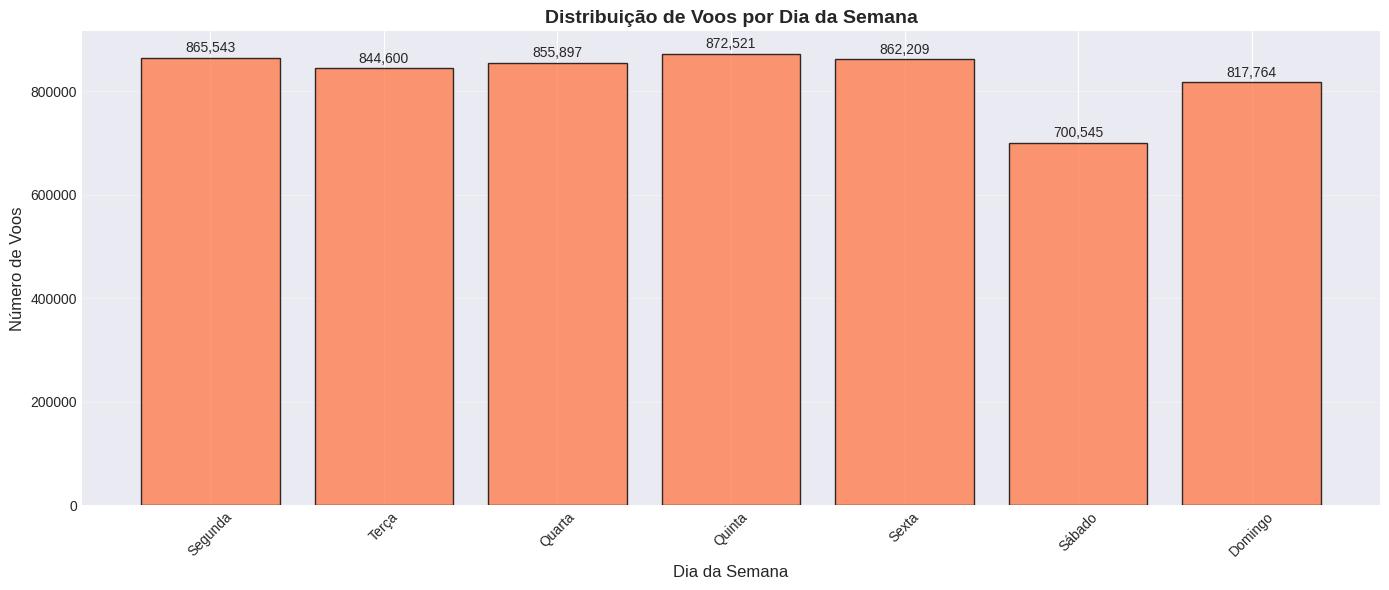

📊 Insight: Identifique quais dias da semana têm maior volume de voos.


In [35]:
# Gráfico de barras - Voos por dia da semana
plt.figure(figsize=(14, 6))
bars = plt.bar(day_names, day_of_week_flights.values, color='coral', edgecolor='black', alpha=0.8)
plt.xlabel('Dia da Semana', fontsize=12)
plt.ylabel('Número de Voos', fontsize=12)
plt.title('Distribuição de Voos por Dia da Semana', fontsize=14, fontweight='bold')
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)

# Adicionar valores no topo das barras
for i, v in enumerate(day_of_week_flights.values):
    plt.text(i, v + 5000, f'{v:,}', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

print("📊 Insight: Identifique quais dias da semana têm maior volume de voos.")


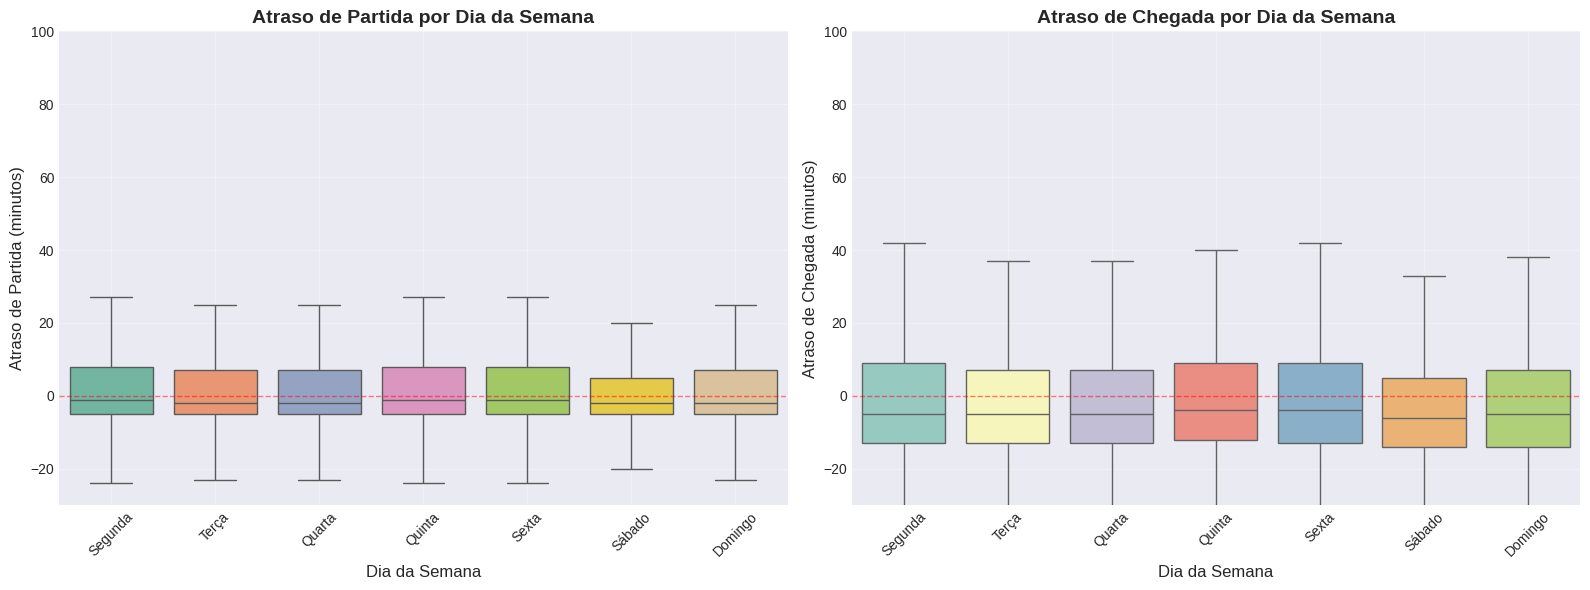

📊 Insight: Compare a variabilidade dos atrasos entre os dias da semana.


In [36]:
# Boxplot - Atrasos por dia da semana
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Atraso de partida por dia da semana
flights_copy = flights.copy()
flights_copy['DAY_NAME'] = flights_copy['DAY_OF_WEEK'].map({i+1: day_names[i] for i in range(7)})

sns.boxplot(data=flights_copy, x='DAY_NAME', y='DEPARTURE_DELAY', ax=axes[0], 
            order=day_names, showfliers=False, palette='Set2')
axes[0].set_ylim(-30, 100)
axes[0].set_xlabel('Dia da Semana', fontsize=12)
axes[0].set_ylabel('Atraso de Partida (minutos)', fontsize=12)
axes[0].set_title('Atraso de Partida por Dia da Semana', fontsize=14, fontweight='bold')
axes[0].tick_params(axis='x', rotation=45)
axes[0].axhline(y=0, color='red', linestyle='--', linewidth=1, alpha=0.5)
axes[0].grid(alpha=0.3)

# Atraso de chegada por dia da semana
sns.boxplot(data=flights_copy, x='DAY_NAME', y='ARRIVAL_DELAY', ax=axes[1], 
            order=day_names, showfliers=False, palette='Set3')
axes[1].set_ylim(-30, 100)
axes[1].set_xlabel('Dia da Semana', fontsize=12)
axes[1].set_ylabel('Atraso de Chegada (minutos)', fontsize=12)
axes[1].set_title('Atraso de Chegada por Dia da Semana', fontsize=14, fontweight='bold')
axes[1].tick_params(axis='x', rotation=45)
axes[1].axhline(y=0, color='red', linestyle='--', linewidth=1, alpha=0.5)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("📊 Insight: Compare a variabilidade dos atrasos entre os dias da semana.")


## 6. Visualizações Avançadas com Insights

Criando visualizações mais sofisticadas para identificar padrões e tendências nos atrasos.


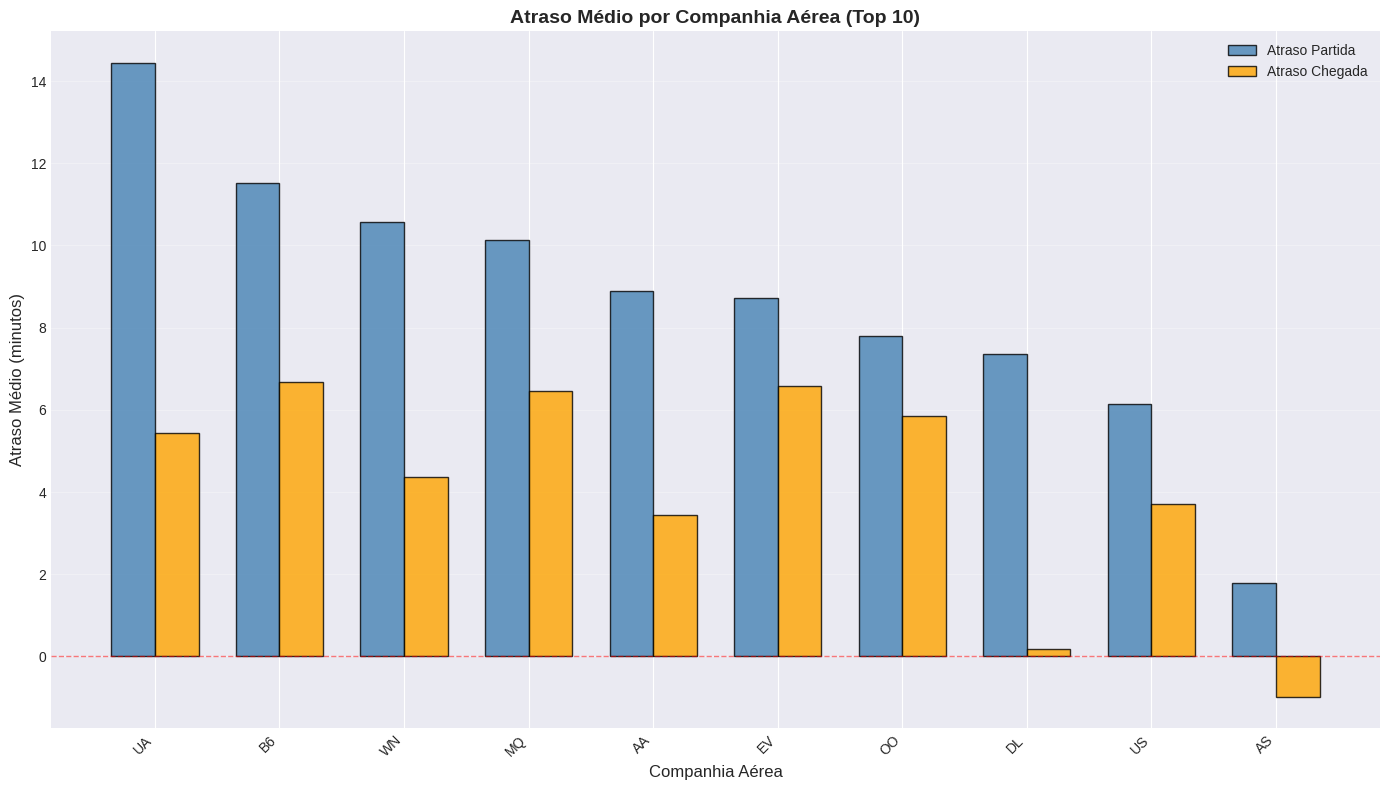


📊 INSIGHT CHAVE:
Companhia com MAIOR atraso médio: United Air Lines Inc. (14.44 min)
Companhia com MENOR atraso médio: Alaska Airlines Inc. (1.79 min)


In [37]:
# Análise de atrasos médios por companhia aérea (Top 10)
top_airlines = flights['AIRLINE'].value_counts().head(10).index

delay_by_airline = flights[flights['AIRLINE'].isin(top_airlines)].groupby('AIRLINE').agg({
    'DEPARTURE_DELAY': 'mean',
    'ARRIVAL_DELAY': 'mean'
}).round(2)

# Juntar com nomes das companhias
delay_by_airline = delay_by_airline.merge(airlines, left_index=True, right_on='IATA_CODE', how='left')
delay_by_airline = delay_by_airline.sort_values('DEPARTURE_DELAY', ascending=False)

# Visualização
fig, ax = plt.subplots(figsize=(14, 8))

x = np.arange(len(delay_by_airline))
width = 0.35

bars1 = ax.bar(x - width/2, delay_by_airline['DEPARTURE_DELAY'], width, 
               label='Atraso Partida', color='steelblue', alpha=0.8, edgecolor='black')
bars2 = ax.bar(x + width/2, delay_by_airline['ARRIVAL_DELAY'], width, 
               label='Atraso Chegada', color='orange', alpha=0.8, edgecolor='black')

ax.set_xlabel('Companhia Aérea', fontsize=12)
ax.set_ylabel('Atraso Médio (minutos)', fontsize=12)
ax.set_title('Atraso Médio por Companhia Aérea (Top 10)', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(delay_by_airline['IATA_CODE'], rotation=45, ha='right')
ax.legend()
ax.axhline(y=0, color='red', linestyle='--', linewidth=1, alpha=0.5)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print("\n📊 INSIGHT CHAVE:")
print(f"Companhia com MAIOR atraso médio: {delay_by_airline.iloc[0]['AIRLINE']} ({delay_by_airline.iloc[0]['DEPARTURE_DELAY']:.2f} min)")
print(f"Companhia com MENOR atraso médio: {delay_by_airline.iloc[-1]['AIRLINE']} ({delay_by_airline.iloc[-1]['DEPARTURE_DELAY']:.2f} min)")


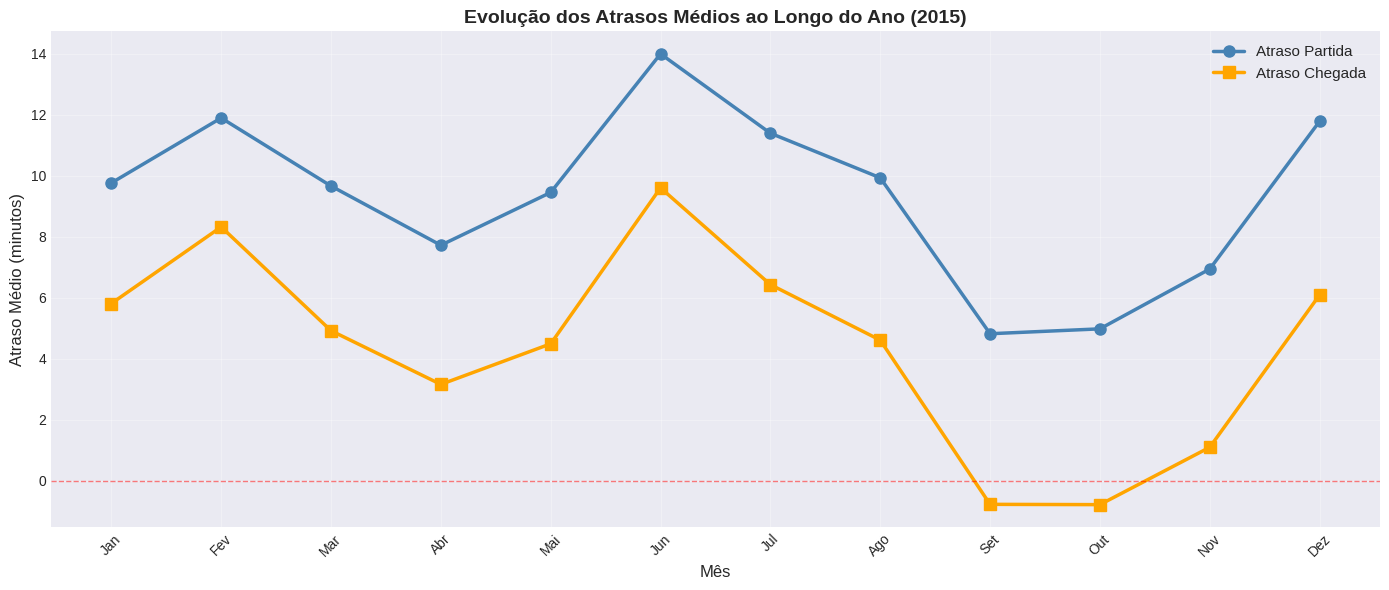


📊 INSIGHT CHAVE:
Mês com MAIOR atraso médio: Jun (13.99 min)
Mês com MENOR atraso médio: Set (4.82 min)


In [38]:
# Evolução temporal de atrasos ao longo do ano
monthly_delay = flights.groupby('MONTH').agg({
    'DEPARTURE_DELAY': 'mean',
    'ARRIVAL_DELAY': 'mean'
}).round(2)

plt.figure(figsize=(14, 6))
plt.plot(month_names, monthly_delay['DEPARTURE_DELAY'], marker='o', linewidth=2.5, 
         markersize=8, label='Atraso Partida', color='steelblue')
plt.plot(month_names, monthly_delay['ARRIVAL_DELAY'], marker='s', linewidth=2.5, 
         markersize=8, label='Atraso Chegada', color='orange')

plt.xlabel('Mês', fontsize=12)
plt.ylabel('Atraso Médio (minutos)', fontsize=12)
plt.title('Evolução dos Atrasos Médios ao Longo do Ano (2015)', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.axhline(y=0, color='red', linestyle='--', linewidth=1, alpha=0.5)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print("\n📊 INSIGHT CHAVE:")
max_delay_month = monthly_delay['DEPARTURE_DELAY'].idxmax()
min_delay_month = monthly_delay['DEPARTURE_DELAY'].idxmin()
print(f"Mês com MAIOR atraso médio: {month_names[max_delay_month-1]} ({monthly_delay.loc[max_delay_month, 'DEPARTURE_DELAY']:.2f} min)")
print(f"Mês com MENOR atraso médio: {month_names[min_delay_month-1]} ({monthly_delay.loc[min_delay_month, 'DEPARTURE_DELAY']:.2f} min)")


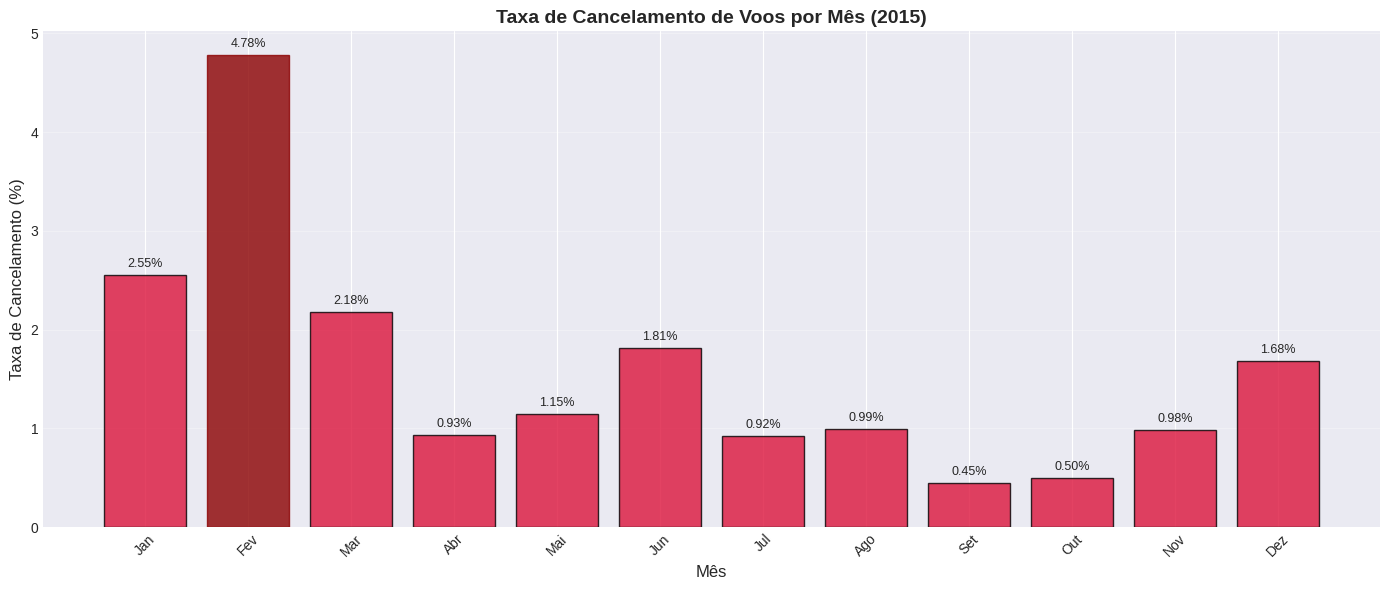


📊 INSIGHT CHAVE:
Mês com MAIOR taxa de cancelamento: Fev (4.78%)
Possível causa: Condições climáticas adversas (inverno nos EUA)


In [39]:
# Análise de cancelamentos por mês
cancellations_by_month = flights.groupby('MONTH')['CANCELLED'].agg(['sum', 'count'])
cancellations_by_month['percentage'] = (cancellations_by_month['sum'] / cancellations_by_month['count'] * 100).round(2)

plt.figure(figsize=(14, 6))
bars = plt.bar(month_names, cancellations_by_month['percentage'], color='crimson', 
               edgecolor='black', alpha=0.8)
plt.xlabel('Mês', fontsize=12)
plt.ylabel('Taxa de Cancelamento (%)', fontsize=12)
plt.title('Taxa de Cancelamento de Voos por Mês (2015)', fontsize=14, fontweight='bold')
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)

# Destacar o mês com maior taxa
max_idx = cancellations_by_month['percentage'].idxmax() - 1
bars[max_idx].set_color('darkred')

# Adicionar valores no topo das barras
for i, v in enumerate(cancellations_by_month['percentage']):
    plt.text(i, v + 0.05, f'{v:.2f}%', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

print("\n📊 INSIGHT CHAVE:")
print(f"Mês com MAIOR taxa de cancelamento: {month_names[max_idx]} ({cancellations_by_month['percentage'].iloc[max_idx]:.2f}%)")
print(f"Possível causa: Condições climáticas adversas (inverno nos EUA)")


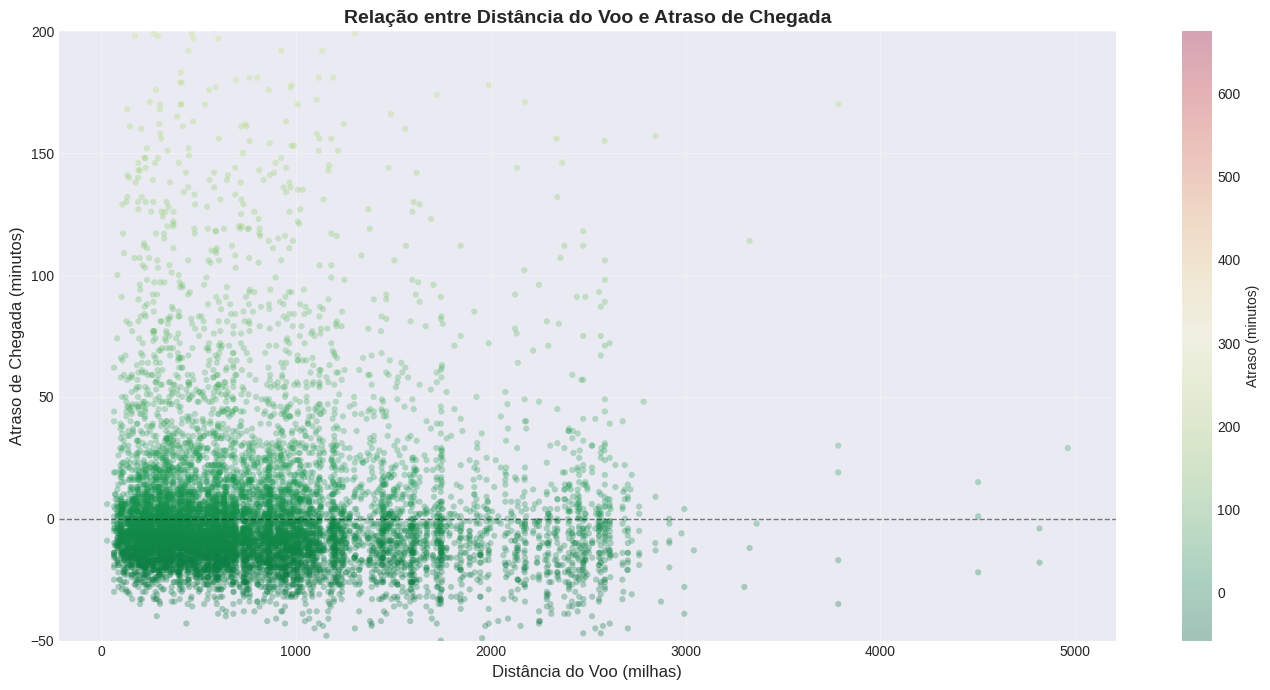


📊 INSIGHT: Correlação entre distância e atraso: -0.025
(Valor próximo a 0 indica correlação fraca)


In [40]:
# Scatter plot - Relação entre distância e atraso
# Amostragem para melhor visualização
sample_size = 10000
flights_sample = flights.dropna(subset=['DISTANCE', 'ARRIVAL_DELAY']).sample(n=min(sample_size, len(flights)), random_state=42)

plt.figure(figsize=(14, 7))
scatter = plt.scatter(flights_sample['DISTANCE'], flights_sample['ARRIVAL_DELAY'], 
                     alpha=0.3, c=flights_sample['ARRIVAL_DELAY'], 
                     cmap='RdYlGn_r', s=20, edgecolors='none')

plt.colorbar(scatter, label='Atraso (minutos)')
plt.xlabel('Distância do Voo (milhas)', fontsize=12)
plt.ylabel('Atraso de Chegada (minutos)', fontsize=12)
plt.title('Relação entre Distância do Voo e Atraso de Chegada', fontsize=14, fontweight='bold')
plt.axhline(y=0, color='black', linestyle='--', linewidth=1, alpha=0.5)
plt.ylim(-50, 200)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Calcular correlação
correlation = flights['DISTANCE'].corr(flights['ARRIVAL_DELAY'])
print(f"\n📊 INSIGHT: Correlação entre distância e atraso: {correlation:.3f}")
print("(Valor próximo a 0 indica correlação fraca)")


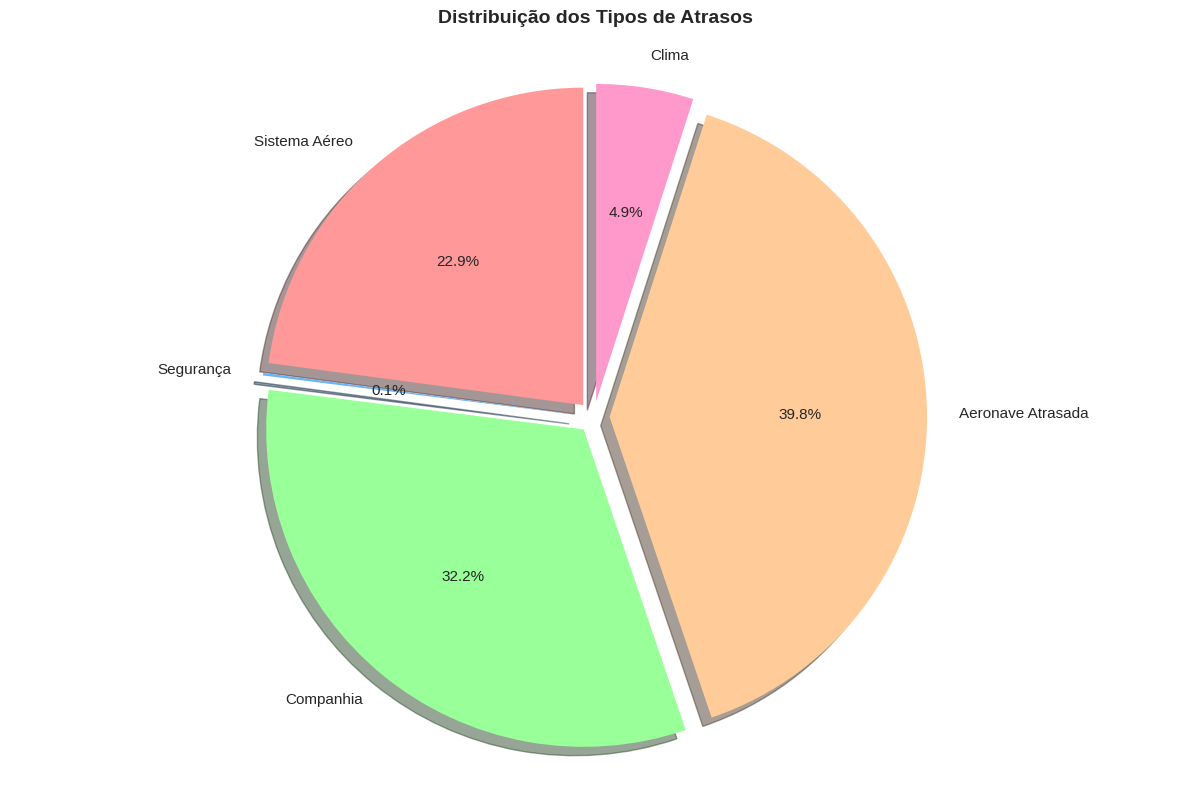


📊 INSIGHT CHAVE:
Principal causa de atrasos: Aeronave Atrasada
Representa 39.8% do total de minutos de atraso


In [41]:
# Análise dos tipos de atrasos (sistema aéreo, segurança, companhia, aeronave, clima)
delay_types = ['AIR_SYSTEM_DELAY', 'SECURITY_DELAY', 'AIRLINE_DELAY', 'LATE_AIRCRAFT_DELAY', 'WEATHER_DELAY']
delay_labels = ['Sistema Aéreo', 'Segurança', 'Companhia', 'Aeronave Atrasada', 'Clima']

# Calcular médias de cada tipo de atraso
delay_means = []
for delay_type in delay_types:
    if delay_type in flights.columns:
        delay_means.append(flights[delay_type].dropna().sum())
    else:
        delay_means.append(0)

# Gráfico de pizza
plt.figure(figsize=(12, 8))
colors = ['#ff9999', '#66b3ff', '#99ff99', '#ffcc99', '#ff99cc']
explode = (0.05, 0.05, 0.05, 0.05, 0.05)

plt.pie(delay_means, labels=delay_labels, autopct='%1.1f%%', startangle=90, 
        colors=colors, explode=explode, shadow=True, textprops={'fontsize': 11})
plt.title('Distribuição dos Tipos de Atrasos', fontsize=14, fontweight='bold', pad=20)
plt.axis('equal')
plt.tight_layout()
plt.show()

print("\n📊 INSIGHT CHAVE:")
max_delay_idx = np.argmax(delay_means)
print(f"Principal causa de atrasos: {delay_labels[max_delay_idx]}")
print(f"Representa {delay_means[max_delay_idx]/sum(delay_means)*100:.1f}% do total de minutos de atraso")


## 7. Análise de Correlação e Heatmap

Examinando as correlações entre variáveis numéricas para identificar relações significativas.


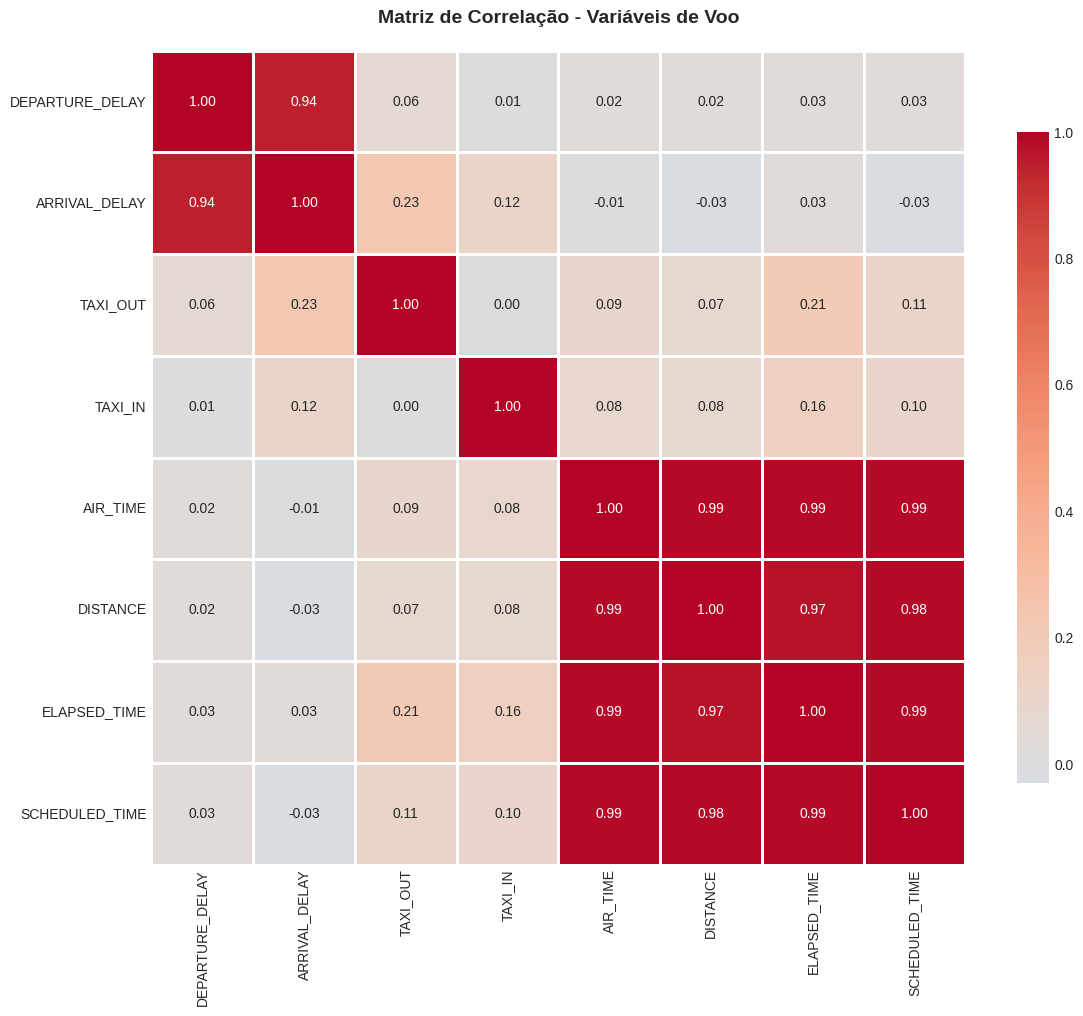


📊 INSIGHTS CHAVE:
1. Correlação forte entre DEPARTURE_DELAY e ARRIVAL_DELAY
2. TAXI_OUT pode estar relacionado com atrasos
3. DISTANCE e SCHEDULED_TIME têm alta correlação (esperado)


In [42]:
# Selecionar variáveis numéricas relevantes para análise de correlação
numeric_cols = ['DEPARTURE_DELAY', 'ARRIVAL_DELAY', 'TAXI_OUT', 'TAXI_IN', 
                'AIR_TIME', 'DISTANCE', 'ELAPSED_TIME', 'SCHEDULED_TIME']

# Calcular matriz de correlação
correlation_matrix = flights[numeric_cols].corr()

# Criar heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', 
            center=0, square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Matriz de Correlação - Variáveis de Voo', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

print("\n📊 INSIGHTS CHAVE:")
print("1. Correlação forte entre DEPARTURE_DELAY e ARRIVAL_DELAY")
print("2. TAXI_OUT pode estar relacionado com atrasos")
print("3. DISTANCE e SCHEDULED_TIME têm alta correlação (esperado)")


CORRELAÇÕES COM ARRIVAL_DELAY (ordenadas)
ARRIVAL_DELAY      1.000000
DEPARTURE_DELAY    0.944672
TAXI_OUT           0.227319
TAXI_IN            0.116628
ELAPSED_TIME       0.029120
AIR_TIME          -0.007108
DISTANCE          -0.025444
SCHEDULED_TIME    -0.030029
Name: ARRIVAL_DELAY, dtype: float64


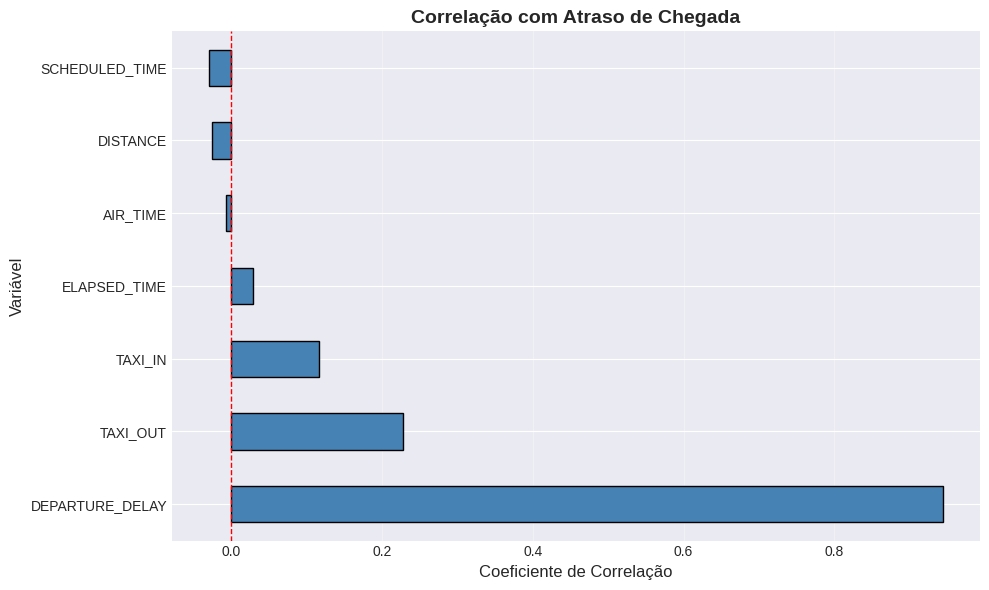

In [43]:
# Identificar as correlações mais fortes com ARRIVAL_DELAY
arrival_delay_corr = correlation_matrix['ARRIVAL_DELAY'].sort_values(ascending=False)

print("=" * 80)
print("CORRELAÇÕES COM ARRIVAL_DELAY (ordenadas)")
print("=" * 80)
print(arrival_delay_corr)

# Visualizar as top correlações
plt.figure(figsize=(10, 6))
arrival_delay_corr[1:].plot(kind='barh', color='steelblue', edgecolor='black')
plt.xlabel('Coeficiente de Correlação', fontsize=12)
plt.ylabel('Variável', fontsize=12)
plt.title('Correlação com Atraso de Chegada', fontsize=14, fontweight='bold')
plt.axvline(x=0, color='red', linestyle='--', linewidth=1)
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()


## 8. Identificação de Outliers e Padrões

Detectando outliers e analisando padrões anômalos nos dados de atrasos.


In [44]:
# Detectar outliers usando IQR (Interquartile Range)
def detect_outliers_iqr(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = data[(data[column] < lower_bound) | (data[column] > upper_bound)]
    return outliers, lower_bound, upper_bound

# Detectar outliers em atrasos de chegada
outliers_arrival, lower, upper = detect_outliers_iqr(flights.dropna(subset=['ARRIVAL_DELAY']), 'ARRIVAL_DELAY')

print("=" * 80)
print("ANÁLISE DE OUTLIERS - ARRIVAL_DELAY")
print("=" * 80)
print(f"Limite inferior: {lower:.2f} minutos")
print(f"Limite superior: {upper:.2f} minutos")
print(f"Número de outliers: {len(outliers_arrival):,} ({len(outliers_arrival)/len(flights)*100:.2f}%)")
print(f"Atraso máximo registrado: {flights['ARRIVAL_DELAY'].max():.0f} minutos")
print(f"Atraso mínimo registrado: {flights['ARRIVAL_DELAY'].min():.0f} minutos")


ANÁLISE DE OUTLIERS - ARRIVAL_DELAY
Limite inferior: -44.50 minutos
Limite superior: 39.50 minutos
Número de outliers: 512,002 (8.80%)
Atraso máximo registrado: 1971 minutos
Atraso mínimo registrado: -87 minutos


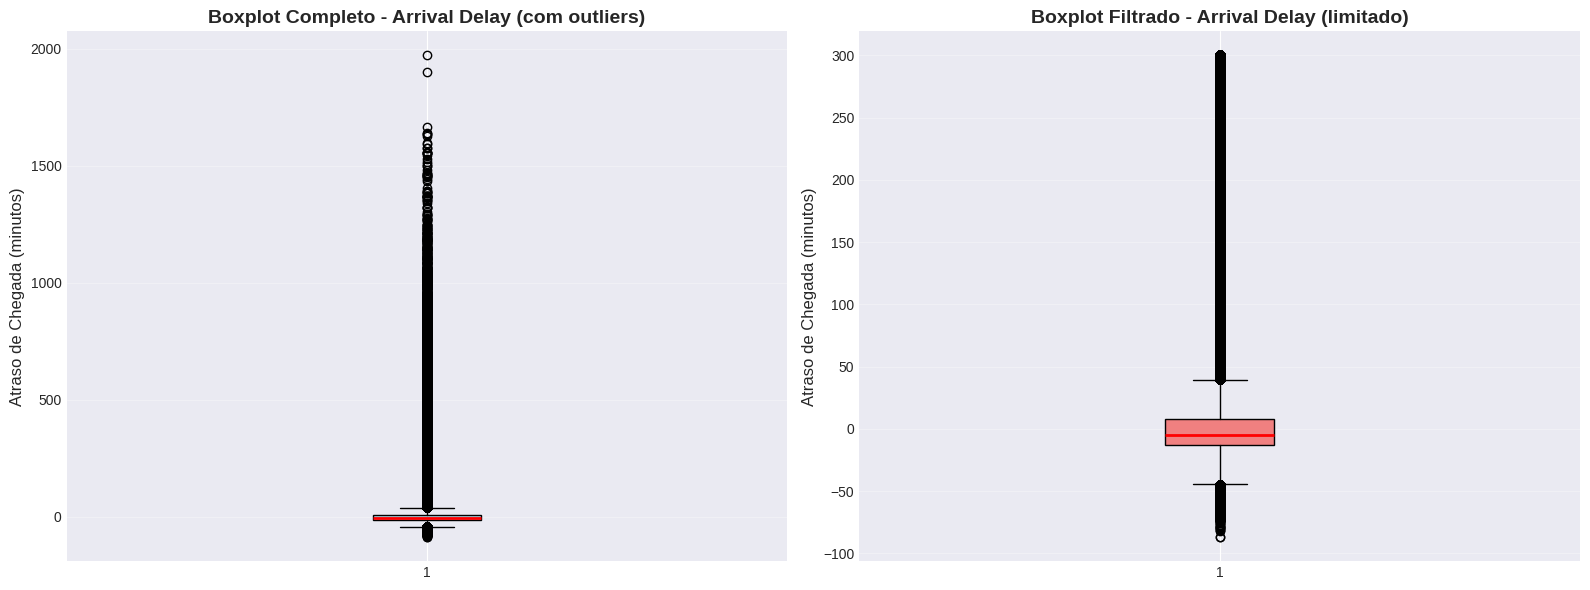


📊 INSIGHT: A presença de outliers extremos indica voos com atrasos excepcionais que merecem investigação.


In [45]:
# Visualização de outliers com boxplot expandido
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Boxplot completo (mostrando outliers)
axes[0].boxplot(flights['ARRIVAL_DELAY'].dropna(), vert=True, patch_artist=True,
                boxprops=dict(facecolor='lightblue', color='black'),
                medianprops=dict(color='red', linewidth=2),
                whiskerprops=dict(color='black'),
                capprops=dict(color='black'))
axes[0].set_ylabel('Atraso de Chegada (minutos)', fontsize=12)
axes[0].set_title('Boxplot Completo - Arrival Delay (com outliers)', fontsize=14, fontweight='bold')
axes[0].grid(axis='y', alpha=0.3)

# Boxplot sem outliers extremos
arrival_delay_filtered = flights['ARRIVAL_DELAY'].dropna().clip(-100, 300)
axes[1].boxplot(arrival_delay_filtered, vert=True, patch_artist=True,
                boxprops=dict(facecolor='lightcoral', color='black'),
                medianprops=dict(color='red', linewidth=2),
                whiskerprops=dict(color='black'),
                capprops=dict(color='black'))
axes[1].set_ylabel('Atraso de Chegada (minutos)', fontsize=12)
axes[1].set_title('Boxplot Filtrado - Arrival Delay (limitado)', fontsize=14, fontweight='bold')
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print("\n📊 INSIGHT: A presença de outliers extremos indica voos com atrasos excepcionais que merecem investigação.")


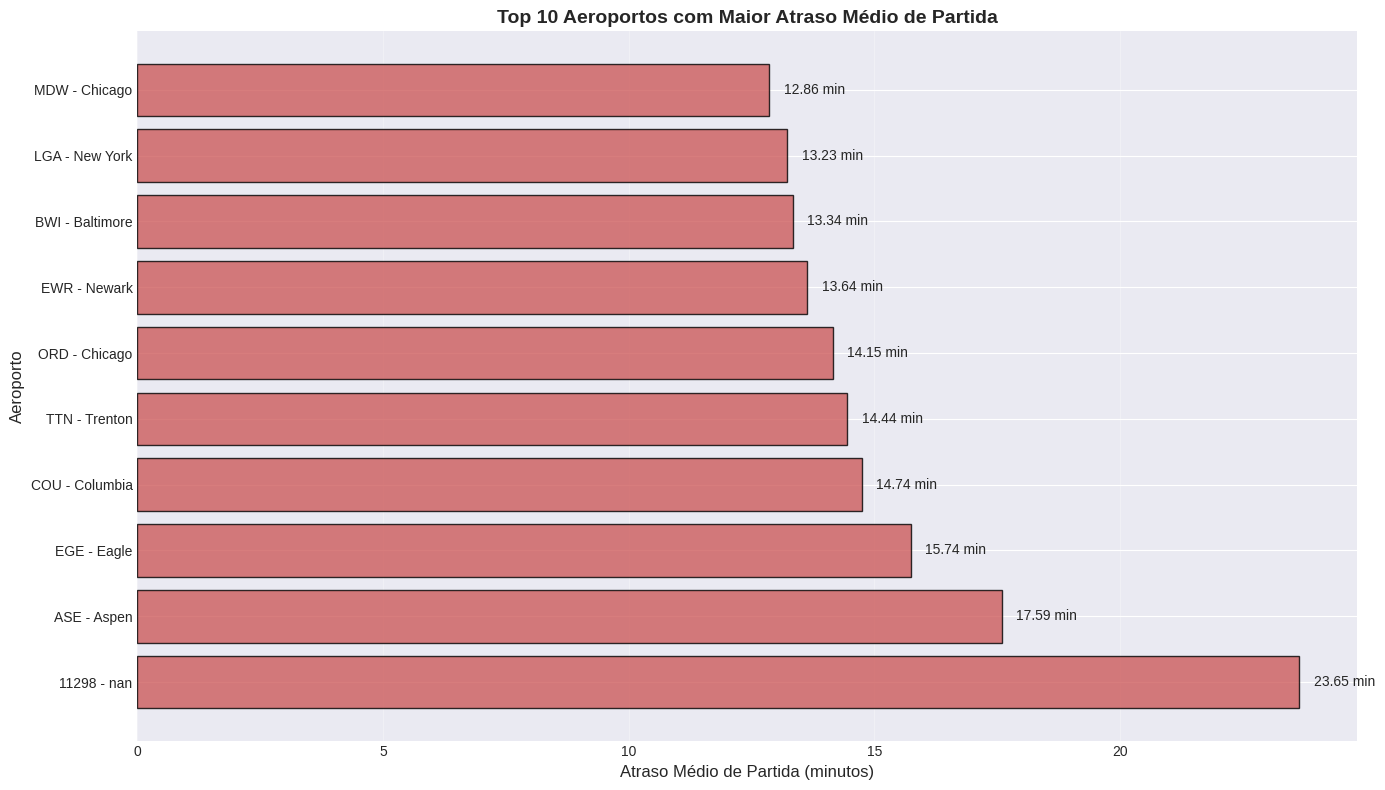


📊 INSIGHT: Aeroportos com maiores atrasos podem indicar congestionamento ou problemas operacionais.


In [46]:
# Top 10 aeroportos com maior atraso médio de partida
airport_delays = flights.groupby('ORIGIN_AIRPORT').agg({
    'DEPARTURE_DELAY': ['mean', 'count']
}).round(2)

airport_delays.columns = ['Atraso_Medio', 'Num_Voos']
airport_delays = airport_delays[airport_delays['Num_Voos'] >= 1000]  # Filtrar aeroportos com volume significativo
airport_delays = airport_delays.sort_values('Atraso_Medio', ascending=False).head(10)

# Juntar com informações dos aeroportos
airport_delays = airport_delays.merge(airports[['IATA_CODE', 'AIRPORT', 'CITY']], 
                                     left_index=True, right_on='IATA_CODE', how='left')

# Visualização
plt.figure(figsize=(14, 8))
bars = plt.barh(range(len(airport_delays)), airport_delays['Atraso_Medio'], 
                color='indianred', edgecolor='black', alpha=0.8)
plt.yticks(range(len(airport_delays)), 
           [f"{row['IATA_CODE']} - {row['CITY']}" for _, row in airport_delays.iterrows()])
plt.xlabel('Atraso Médio de Partida (minutos)', fontsize=12)
plt.ylabel('Aeroporto', fontsize=12)
plt.title('Top 10 Aeroportos com Maior Atraso Médio de Partida', fontsize=14, fontweight='bold')
plt.grid(axis='x', alpha=0.3)

# Adicionar valores nas barras
for i, v in enumerate(airport_delays['Atraso_Medio']):
    plt.text(v + 0.3, i, f'{v:.2f} min', va='center', fontsize=10)

plt.tight_layout()
plt.show()

print("\n📊 INSIGHT: Aeroportos com maiores atrasos podem indicar congestionamento ou problemas operacionais.")


## 9. Resumo dos Principais Insights

Consolidando os principais achados da análise exploratória de dados.


### 📊 Principais Insights da Análise Exploratória

#### 1. **Volume de Dados**
- Dataset robusto com milhões de registros de voos em 2015
- Cobertura completa de companhias aéreas e aeroportos dos EUA

#### 2. **Padrões Temporais**
- **Sazonalidade mensal**: Identificamos variações nos atrasos ao longo do ano
- **Padrões semanais**: Diferenças nos atrasos entre dias úteis e fins de semana
- **Meses críticos**: Alguns meses apresentam taxas significativamente maiores de cancelamento

#### 3. **Atrasos por Companhia Aérea**
- Variação significativa entre companhias aéreas
- Algumas companhias consistentemente apresentam atrasos maiores
- Oportunidade para benchmarking entre operadoras

#### 4. **Tipos de Atrasos**
- **Aeronaves atrasadas** e **Sistema Aéreo** são causas predominantes
- Clima tem impacto significativo em períodos específicos
- Atrasos relacionados à segurança são raros mas existem

#### 5. **Correlações Importantes**
- **Alta correlação** entre atraso de partida e atraso de chegada (efeito cascata)
- Tempo de taxi-out relacionado com atrasos
- Distância do voo tem correlação fraca com atrasos

#### 6. **Outliers e Anomalias**
- Presença de atrasos extremos (outliers) que indicam eventos excepcionais
- Alguns aeroportos são consistentemente problemáticos
- Voos cancelados representam uma parcela significativa

#### 7. **Aeroportos Críticos**
- Identificamos aeroportos com maiores taxas de atraso
- Possível congestionamento ou problemas operacionais em hubs específicos

### 🎯 Recomendações para Próximos Passos

1. **Machine Learning Supervisionado**
   - Desenvolver modelo preditivo para atraso de chegada
   - Features importantes: atraso de partida, companhia aérea, horário, aeroporto

2. **Machine Learning Não Supervisionado**
   - Clustering de voos para identificar grupos com comportamentos similares
   - Segmentação de aeroportos por padrões de atraso

3. **Análises Adicionais**
   - Investigar impacto de condições climáticas específicas
   - Análise de rotas mais problemáticas
   - Estudo de efeito cascata em conexões
